In [65]:
import pandas as pd
from pandas import read_csv
import plotly.express as px
import numpy as np
import pandas as pd
from antropy import spectral_entropy, app_entropy, sample_entropy
from scipy.stats import variation
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import DecomposeResult, seasonal_decompose
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,SimpleRNN,Input,TimeDistributed,Lambda,GRU,Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Flatten
from ipywidgets import interact, IntSlider
from scipy.signal import find_peaks
from ipywidgets import Tab, Output
from IPython.display import display
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import interact, IntSlider
from typing import Dict, List, Tuple, Any
from ipywidgets import Layout, VBox



# Functions: 

In [66]:
def compile_fit_with_tabs(model: Sequential,X_train: np.ndarray,y_train: np.ndarray,X_val: np.ndarray,y_val: np.ndarray,epochs: int = 50,batch_size: int = 8,patience: int = 10) -> Any:
    
    # Define a layout to make widgets use the full width
    full_width_layout = Layout(width='100%')
    summary_out = Output(layout=full_width_layout)
    fit_out = Output(layout=full_width_layout)
    
    # Create the Tab widget
    tab_widget = Tab(children=[summary_out, fit_out], layout=full_width_layout)
    tab_widget.set_title(0, 'Model Summary')
    tab_widget.set_title(1, 'Model Training')
    
    # Display the tab widget
    display(VBox([tab_widget], layout=Layout(width='100%', align_items='stretch')))
    
    with summary_out:
        model.compile(optimizer='adam', loss='mse')
        model.summary()
    
    with fit_out:
        es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=1,
            callbacks=[es]
        )
        
    return history

In [67]:
def plot_loss_comparison(histories_list: List[Tuple[str, Any, str, str]],title: str = "Comparison Loss Models",width: int = 1150, height: int = 500):
    
    fig = go.Figure()

    # Loop through the list of histories provided
    for model_name, history, color, marker in histories_list:
        # Add the training loss line
        fig.add_trace(go.Scatter(y=history.history["loss"],name=f"{model_name} Train",line=dict(color=color)))
        fig.add_trace(go.Scatter(y=history.history["val_loss"],name=f"{model_name} Val",line=dict(color=color, dash='dot'),mode='lines+markers',marker=dict(symbol=marker)))
    fig.update_layout(title=title, xaxis_title="Epoch", yaxis_title="MSE",width=width, height=height)
    fig.show()


def plot_one_step_prediction(full_index: np.ndarray,series_orig: np.ndarray,pred_index: np.ndarray,predictions_list: List[Tuple[str, np.ndarray, str, str]],title: str = "Predictions One-step ahead",width: int = 1150,height: int = 500):
    fig = go.Figure()

    #Plots the original time series and overlays the one-step-ahead test predictions.
    fig.add_trace(go.Scatter(x=full_index, y=series_orig, mode='lines',name='True signal', line=dict(color='orange', width=1)))
    # Loop through all provided predictions and plot them
    for name, y_pred, color, marker in predictions_list:
        fig.add_trace(go.Scatter(x=pred_index, y=y_pred, mode='lines+markers',name=name, line=dict(color=color), marker=dict(symbol=marker)))
    fig.update_layout(title=title, xaxis_title="Time step", yaxis_title="Sunspots",width=width, height=height)
    fig.show()

def plot_metrics_comparison(metrics_dict: Dict[str, Dict[str, float]],title: str = "Comparison Performance Models",width: int = 1150,height: int = 500):
    #Create bar charts to compare MSE and MAE metrics for different models.
    models = list(metrics_dict.keys())
    mse_values = [metrics_dict[model]["MSE"] for model in models]
    mae_values = [metrics_dict[model]["MAE"] for model in models]
    fig = make_subplots(rows=1, cols=2, subplot_titles=("MSE", "MAE"))
    fig.add_trace(go.Bar(x=models, y=mse_values, marker_color="royalblue", name="MSE"),row=1, col=1)
    fig.add_trace(go.Bar(x=models, y=mae_values, marker_color="firebrick", name="MAE"),row=1, col=2)
    fig.update_layout(title_text=title, template="plotly_white", showlegend=False, font=dict(size=14),width=width, height=height)
    fig.show()

In [68]:
def show_results_tabs(
        
        plot_type: str,  #'one_step' or 'multi_step'
        
        histories_list: List[Tuple[str, Any, str, str]],
        loss_title: str,
        metrics_dict: Dict[str, Dict[str, float]],
        metrics_title: str,
        series_orig: np.ndarray,
        plot_width: int = 1150, 
        plot_height: int = 500,
        
        # Arguments for 'one_step' 
        full_index: np.ndarray = None,
        pred_index: np.ndarray = None,
        predictions_list: List[Tuple[str, np.ndarray, str, str]] = None,
        pred_title: str = "One-step Prediction",
        
        # Arguments for 'multi_step' 
        Y_test_orig: np.ndarray = None,
        predictions_dict: Dict[str, np.ndarray] = None,
        test_offset: int = None,
        win: int = None,
        n_step: int = None,
        last_n: int = 125,
        step_slider: int = 20
    ):
    
    full_width_layout = Layout(width='100%')

    if plot_type == 'one_step':
        # Create Output widgets for each plot
        loss_out = Output(layout=full_width_layout)
        pred_out = Output(layout=full_width_layout)
        metrics_out = Output(layout=full_width_layout)
        # Create the Tab widget
        tab_widget = Tab(children=[loss_out, pred_out, metrics_out], layout=full_width_layout)
        tab_widget.set_title(0, 'Training Loss')
        tab_widget.set_title(1, 'Test Predictions (One-Step)')
        tab_widget.set_title(2, 'Test Metrics')
        
        display(VBox([tab_widget], layout=Layout(width='100%', align_items='stretch')))
        
        with loss_out:
            plot_loss_comparison(histories_list, title=loss_title, width=plot_width, height=plot_height)
        with pred_out:
            plot_one_step_prediction(full_index, series_orig, pred_index, predictions_list, title=pred_title, width=plot_width, height=plot_height)
        with metrics_out:
            plot_metrics_comparison(metrics_dict, title=metrics_title, width=plot_width, height=plot_height)

    elif plot_type == 'multi_step':
        N = Y_test_orig.shape[0]
        colors = px.colors.qualitative.Plotly
        symbols = ['circle', 'diamond', 'star', 'x', 'cross', 'triangle-up']

        # function that will be called by the interactive slider
        def plot_interactive_tabs(idx):
            idx = int(idx)

            # Create Output widgets for each plot
            pred_out = Output(layout=full_width_layout)
            loss_out = Output(layout=full_width_layout)
            metrics_out = Output(layout=full_width_layout)

            # Create the Tab widget
            tab_widget = Tab(children=[pred_out, loss_out, metrics_out], layout=full_width_layout)
            tab_widget.set_title(0, 'Interactive Prediction (Multi-Step)')
            tab_widget.set_title(1, 'Training Loss')
            tab_widget.set_title(2, 'Test Metrics')
            
            display(VBox([tab_widget], layout=Layout(width='100%', align_items='stretch')))

            with pred_out:

                # Calculate indices for plotting
                pred_start = test_offset + idx + win    
                plot_end = pred_start + n_step
                plot_start = max(0, pred_start - last_n)    

                # Get the segment of the original series to plot 
                plot_index = np.arange(plot_start, plot_end)
                seg = series_orig[plot_start:plot_end]

                # Split into observed data and true future data
                before_mask = plot_index < pred_start
                index_before_pred = plot_index[before_mask]
                se = seg[before_mask]

                pred_index = np.arange(pred_start, pred_start + n_step)
                reals = Y_test_orig[idx] 
                
                fig_pred = go.Figure()
                
                if len(index_before_pred) > 0:
                    fig_pred.add_trace(go.Scatter(x=index_before_pred, y=se, mode='lines', name='True signal (observed)', line=dict(color='black', width=2)))
                
                fig_pred.add_trace(go.Scatter(x=pred_index, y=reals, mode='lines', name='True signal (prediction period)', line=dict(color='red', width=2, dash='dash')))
                
                for i, (name, y_pred_array) in enumerate(predictions_dict.items()):
                    fig_pred.add_trace(go.Scatter(x=pred_index, y=y_pred_array[idx], mode='lines+markers',name=name, line=dict(color=colors[i % len(colors)]), marker=dict(symbol=symbols[i % len(symbols)])))

                fig_pred.add_vline(x=pred_start, line=dict(color='red', width=2, dash='dot'), annotation_text="Prediction start", annotation_position="top right")
                
                fig_pred.update_layout(title=f"Sample {idx} — Comparison: {win} Input steps + {n_step} Prediction steps", xaxis_title="Time step", yaxis_title="Sunspots", height=plot_height, width=plot_width)
                fig_pred.show()

            with loss_out:
                plot_loss_comparison(histories_list, title=loss_title, width=plot_width, height=plot_height)
                
            with metrics_out:
                plot_metrics_comparison(metrics_dict, title=metrics_title, width=plot_width, height=plot_height)
        
        interact(
            plot_interactive_tabs,idx=IntSlider(min=0, max=N - step_slider, step=step_slider, value=0, description='Test Sample Idx'))

# Task1: 

Load the sunspot dataset from
https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv.
Each row of the dataset refers to a given month in a given year and
contains the monthly mean total sunspot number. You can do plots and/or
visualization of the dataset if you like, but it is not mandatory.
I suggest to scale the dataset with the MinMaxScaler between 0 and 1.

## 1. Load and explore the dataset

### 1.1. Exploration of the dataset 

In [69]:
df = read_csv("monthly-sunspots.csv")
df

,Month,Sunspots
0,1749-01,58.0
1,1749-02,62.6
2,1749-03,70.0
3,1749-04,55.7
4,1749-05,85.0
...,...,...
2815,1983-08,71.8
2816,1983-09,50.3
2817,1983-10,55.8
2818,1983-11,33.3


In [70]:
df.shape

(2820, 2)

We begin by loading the dataset,

We have a total of **2820 records** (rows) and 2 columns ('Month' and 'Sunspots'). As the dataset title implies, each record represents a single month of data.

In [71]:
df.describe()

,Sunspots
count,2820.000000
mean,51.265957
std,43.448971
min,0.000000
25%,15.700000
50%,42.000000
75%,74.925000
max,253.800000


These statistics, especially the **mean** and **std dev**, are a crucial baseline. Later, when we evaluate our models, we can compare our error metrics (like MAE or MSE) against these values. This will help us understand if our model's error is relatively small or large compared to the average value and overall variability of the signal itself.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Month     2820 non-null   object 
 1   Sunspots  2820 non-null   float64
dtypes: float64(1), object(1)
memory usage: 44.2+ KB


Since the non-null count matches the total number of entries, we can confirm that **there are no missing values** in the dataset, which simplifies our preprocessing.

In [73]:
df.isnull().sum()

Month       0
Sunspots    0
dtype: int64

In [74]:
# for comodity of the plots we convert string data in datetime
df['Month'] = pd.to_datetime(df['Month'])

In [75]:
min_date = min(df.Month)
max_date = max(df.Month)

print(f"Start-Date: {min_date}")
print(f"End-Date: {max_date}")

Start-Date: 1749-01-01 00:00:00
End-Date: 1983-12-01 00:00:00


The dataset covers a very long time span, starting from **January 1749** and ending in **December 1983**. This gives us over 230 years of monthly data to analyze.

### 1.2. Signal Visualization 

In [76]:
# https://plotly.com/python/time-series/#time-series-with-range-selector-buttons

fig = px.line(df, x='Month', y="Sunspots",title='Time Series monthly-sunspots.csv')
# fig.update_layout(template = "plotly_dark")
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(count=10, label="10y", step="year", stepmode="backward"),
            dict(count=50, label="50y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)
# fig.update_layout(template = "plotly_dark")
# fig.update_traces(line_color = "red")
fig.show()

From this visualization, we can immediately observe a few key characteristics:
* **Strong Cyclicality:** The signal does not appear random. It has a very strong, repeating pattern of rising to a peak and falling to a trough.
* **Periodicity:** Visually, this cycle seems to repeat roughly every **11 years**.

* **No Obvious Outliers:** The signal seems to be quite clean. Even the very high peaks around 1778 and 1836 appear to be part of the natural. Zooming in confirms they are part of the expected pattern.

* **Forecastability:** A signal with such a regular, strong cyclical pattern and no significant outliers is typically a good candidate for time series forecasting.

To be certain of its forecastability, we will next move on to more formal analyses by examining its forecastability metrics and analyzing its **Autocorrelation plot**.

### 1.3. Signal Distribution 

In [77]:
# From https://plotly.com/python/distplot

fig = px.histogram(df, x="Sunspots", 
                   nbins=100,
                   marginal="box", # or violin, rug
                   title="Distribution monthly-sunsposts.csv")

# fig.update_layout(template = "plotly_dark")
# fig.update_traces(marker_color = "red")

fig.show()

The histogram, combined with the marginal boxplot, shows the distribution of the 'Sunspots' values.

We can clearly see that the data **is not normally distributed**.
* It is heavily **right-skewed**. The vast majority of months have a low sunspot count, with a large peak clustered between 0 and 50.
* A long tail extends to the right, indicating that very high sunspot counts are much rarer.

**Important Note on Outliers:** This plot makes us question the validity of some of these high-value outliers. After in-depth research on the historical range of possible sunspot values, a maximum of **215.5** was found. This information allows us to treat any values in our dataset above this threshold as presumed anomalies. We can remove them to get a cleaner, more accurate signal for modeling.

In [78]:
threshold = 215.5

outliers_count = (df['Sunspots'] > threshold).sum()
print(f"Found {outliers_count} values above the {threshold} threshold.")

df.loc[df['Sunspots'] > threshold, 'Sunspots'] = np.nan
print(f"Total NaNs after replacement: {df['Sunspots'].isnull().sum()}")

df['Sunspots'] = df['Sunspots'].interpolate(method='linear')
print(f"Total NaNs after interpolation: {df['Sunspots'].isnull().sum()}")

Found 5 values above the 215.5 threshold.
Total NaNs after replacement: 5
Total NaNs after interpolation: 0


## 2. Forecastability index

In [79]:
def forecastability_index(values, fs=1.0):
    return pd.DataFrame({
        "spectral_entropy": [spectral_entropy(values, sf=fs, method='welch', normalize=True)],
        "approx_entropy": [app_entropy(values)],
        "sample_entropy": [sample_entropy(values)],
        "variance_ratio": [np.var(np.diff(values)) / np.var(values)]
    })

In [80]:
print(forecastability_index(df.Sunspots))

   spectral_entropy  approx_entropy  sample_entropy  variance_ratio
0          0.430018        1.064524        0.649453        0.153959


Both metrics confirm the signal is highly regular, non-random, and very forecastable.

## 3. Autocorrelation plot

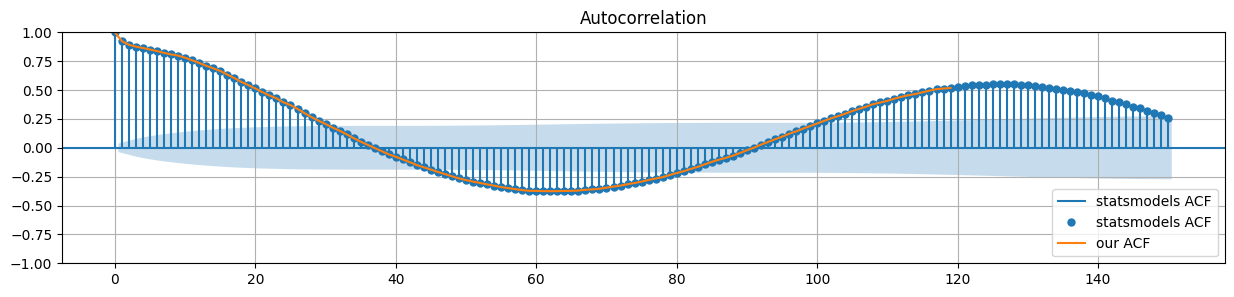

In [ ]:
acf = lambda x, k: ((x.shift(k)-x.mean())*(x-x.mean())).sum() / x.std()**2 / len(x)

fig, ax = plt.subplots(figsize=(15, 3))

plot_acf(df.Sunspots, lags=150, ax=ax, label='statsmodels ACF');
plt.plot([acf(df.Sunspots, k) for k in range(120)], label='our ACF')
plt.grid()
plt.legend(loc='lower right')

In [82]:
acf_vals = np.array([acf(df.Sunspots, k) for k in range(150)])
peaks, _ = find_peaks(acf_vals, height=0)  

print("Index x:", peaks)
print("Values:", acf_vals[peaks])

Index x: [126 128]
Values: [0.55033245 0.55091675]


The ACF plot strongly confirms the signal's seasonality. 

* The find_peaks code identifies a clear new peak at **lag 126-128**.
* This confirms the signal has a long-term memory with a period of approximately **126 months (10.5 years)**, matching the known solar cycle. This makes it highly predictable.

## 4. Seasonality Decomposition

In [83]:
################ Taked from https://gist.github.com/tomron/8798256fcee5438edd58c17654adf443 ###################


def plot_seasonal_decompose(result:DecomposeResult, dates:pd.Series=None, title:str="Seasonal Decompdrition"):
    x_values = dates if dates is not None else np.arange(len(result.observed))
    return (
        make_subplots(
            rows=4,
            cols=1,
            subplot_titles=["Observed", "Trend", "Seasonal", "Residuals"],
        )
        .add_trace(
            go.Scatter(x=x_values, y=result.observed, mode="lines", name='Observed'),
            row=1,
            col=1,
        )
        .add_trace(
            go.Scatter(x=x_values, y=result.trend, mode="lines", name='Trend'),
            row=2,
            col=1,
        )
        .add_trace(
            go.Scatter(x=x_values, y=result.seasonal, mode="lines", name='Seasonal'),
            row=3,
            col=1,
        )
        .add_trace(
            go.Scatter(x=x_values, y=result.resid, mode="lines", name='Residual'),
            row=4,
            col=1,
        )
        .update_layout(
            height=900, title=f'<b>{title}</b>', margin={'t':100}, title_x=0.5, showlegend=False#, template = "plotly_dark"
        )
    )

In [84]:
decompdrition = seasonal_decompose(df.Sunspots,model='additive',period=120)
dates = df.Sunspots.index

stl = STL(df.Sunspots, period=125, robust=True)
decompdrition_stl = stl.fit()

fig = plot_seasonal_decompose(decompdrition_stl,dates=dates,title=f"Decompdrizione STL period (10 years)")
fig.show()

To confirm our visual and ACF analysis, we perform an **STL**. We set the period to **125 months** based on the peak we found in the autocorrelation plot.

## 5. Stationarity Checks

In [85]:
def check_stationarity(signal,title):
    adf_test = adfuller(signal)
    kpss_test = kpss(signal)
    stationarity_tests = pd.Series({'adf pval': adf_test[1], 'kpss pval': kpss_test[1]},name=f'stationarity_tests_for_{title}')
    return stationarity_tests


check_stationarity(df.Sunspots, "Sunspots") 

adf pval     1.884930e-16
kpss pval    6.025123e-02
Name: stationarity_tests_for_Sunspots, dtype: float64

## 6. Apply scaler

In [86]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
df['Sunspots_scaled'] = scaler.fit_transform(df[['Sunspots']])
df.head(1)

,Month,Sunspots,Sunspots_scaled
0,1749-01-01,58.0,0.275012


Finally, we apply a MinMaxScaler to rescale the 'Sunspots' data. 
This is a crucial preprocessing step for neural networks. 

# Task2: 

Organize your dataset such that you have time series of a length you can
decide. You want to predict the mean sunspots number, one month ahead.
Split the dataset into training+validation (80%) and test (20%).

In [87]:
test_ratio = 0.2
val_ratio = 0.2
n_past = 125
series = df["Sunspots_scaled"].values
series = series.reshape(-1,1)


In [88]:
def make_supervised(arr: np.ndarray, n_past: int):
    """
    Create (X, y) per one-step ahead from univariate time series scaled between [0,1].
    X: (n_samples, n_past, 1)
    y: (n_samples, 1)
    """
    X_list, y_list = [], []
    for i in range(n_past, len(arr)):
        X_list.append(arr[i - n_past:i, 0])
        y_list.append(arr[i, 0])
    X = np.array(X_list).reshape(-1, n_past, 1)
    y = np.array(y_list).reshape(-1, 1)
    return X, y

In [89]:
X, y = make_supervised(series, n_past)
print("Shape X:", X.shape, "| Shape y:", y.shape)

n_test = int(len(X) * test_ratio)
X_train_val, X_test = X[:-n_test], X[-n_test:]
y_train_val, y_test = y[:-n_test], y[-n_test:]

n_val = int(len(X_train_val) * val_ratio)
X_train, X_val = X_train_val[:-n_val], X_train_val[-n_val:]
y_train, y_val = y_train_val[:-n_val], y_train_val[-n_val:]

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val  : {X_val.shape}, {y_val.shape}")
print(f"Test : {X_test.shape}, {y_test.shape}")


Shape X: (2695, 125, 1) | Shape y: (2695, 1)
Train: (1725, 125, 1), (1725, 1)
Val  : (431, 125, 1), (431, 1)
Test : (539, 125, 1), (539, 1)


* X (Input): A window of 125 consecutive months.
* y (Output): The 126th month.

This process creates 2695 (X, y) samples. We then split this dataset into **Train (80% of 80%)**, **Validation (20% of 80%)**, and **Test (20%)** sets.

# Task3: 

Build a simple Recurrent Neural Network and train it on the dataset you
built. It should work pretty good. Make a plot that shows the real time
series and the predicted one, highlighting where the predictions on the test
set begin. Compare the performances with a simple Dense network.

In [114]:
patience = 10    
es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

## 1. Simples Recurrent Neural Network 

In [115]:
epochs = 50
batch_size = 8

In [116]:
simple_RNN = Sequential([
    SimpleRNN(60, input_shape=(n_past, 1)),
    Dense(1),
])

In [117]:
history_RNN = compile_fit_with_tabs(
    simple_RNN, X_train, y_train, X_val, y_val, 
    epochs=epochs, batch_size=batch_size, patience=patience
)

## 2. Simples Dense Network

In [118]:
simple_dense = Sequential([
    Flatten(input_shape=(n_past, 1)), 
    Dense(1) 
])

c:\Users\Sergio\.virtualenvs\Advanced_Machine_Learning-orlBGEN5\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [119]:
history_dense = compile_fit_with_tabs(
    simple_dense, X_train, y_train, X_val, y_val, 
    epochs=epochs, batch_size=batch_size, patience=patience
)

## 3. Comparison

In [120]:
y_pred_rnn_scaled = simple_RNN.predict(X_test, verbose=0).reshape(-1,1)
y_pred_rnn = scaler.inverse_transform(y_pred_rnn_scaled).ravel()
y_test_inv = scaler.inverse_transform(y_test).ravel() 

y_pred_dense_scaled = simple_dense.predict(X_test, verbose=0).reshape(-1,1)
y_pred_dense = scaler.inverse_transform(y_pred_dense_scaled).ravel()

full_index = np.arange(len(series))
pred_index = np.arange(len(series)-len(y_test_inv), len(series))
series_orig = scaler.inverse_transform(series.reshape(-1,1)).ravel()

mse_RNN = np.mean((y_pred_rnn - y_test_inv) ** 2)
mae_RNN = np.mean(np.abs(y_pred_rnn - y_test_inv))
mse_dense = np.mean((y_pred_dense - y_test_inv) ** 2)
mae_dense = np.mean(np.abs(y_pred_dense - y_test_inv))

In [121]:
histories_task3 = [
    ("RNN", history_RNN, "red", "x"),
    ("Dense", history_dense, "blue", "circle")
]

predictions_task3 = [
    ("RNN Prediction", y_pred_rnn, "red", "x"),
    ("Dense Prediction", y_pred_dense, "blue", "circle")
]

metrics_task3 = {
    "RNN": {"MSE": mse_RNN, "MAE": mae_RNN},
    "Dense": {"MSE": mse_dense, "MAE": mae_dense}
}

show_results_tabs(
    plot_type='one_step',  
    
    histories_list=histories_task3,
    loss_title="Loss RNN vs Dense (One-Step)",
    metrics_dict=metrics_task3,
    metrics_title="Performance Test Set (One-Step)",
    series_orig=series_orig,
    plot_width=1150,
    plot_height=500,

    full_index=full_index,
    pred_index=pred_index,
    predictions_list=predictions_task3,
    pred_title="One-step ahead prediction — RNN vs Dense"
)

**Important**: 
- The output graph is interactive. At the top, you can click the tabs to switch between the "Training Loss", "Test Predictions (One-Step)", and "Test Metrics" views. There is also the possibility to zoom in.

* **Training Loss :** From the loss plot, we can see two things. First, the **Simple RNN** converges much faster and in fewer epochs. Second, its final validation loss is slightly lower than that of the Dense model, suggesting it was more efficient at learning the underlying patterns. 

* **Test Predictions :** This plot shows the actual predictions overlaid on the original time series. Both the RNN and Dense models track the true signal exceptionally well. They are visually almost indistinguishable. This is expected for a one-step-ahead task, as the signal has high autocorrelation. 

* **Test Metrics Tab:** This tab confirms our visual observation from the prediction plot. The bar charts for both **MSE** and **MAE** are nearly identical for the RNN and the Dense model. 

# Task 4

Perform again Task 3, but this time try to predict up to 6 steps ahead. We
saw two different approaches in class, you should test both of them. Which
one works better? Compare the performances with a simple Dense network.

In [134]:
series_orig = scaler.inverse_transform(series.reshape(-1,1)).ravel()
test_offset = len(X_train)  
step_slider = 20     
win = X_test.shape[1] 
last_n = 125
n_step = 6

In [135]:
def make_supervised_direct(arr: np.ndarray, n_past: int, n_step: int):
    """
    Crea (X, y) per la previsione Direct da una serie temporale univariata.
    X: (n_samples, n_past, 1)
    y: (n_samples, n_step)
    """
    X_list, y_list = [], []
    for i in range(n_past, len(arr) - n_step + 1):
        X_list.append(arr[i - n_past:i, 0])
        y_list.append(arr[i:i + n_step, 0])
    X = np.array(X_list).reshape(-1, n_past, 1)
    y = np.array(y_list).reshape(-1, n_step)
    return X, y

In [136]:
X_dr, y_dr = make_supervised_direct(series, n_past, n_step)
print(f"Shape X (direct): {X_dr.shape} | Shape y (direct): {y_dr.shape}")

n_total = len(X_dr)
n_train = int(n_total * 0.6)
n_val = int(n_total * 0.2)
n_test = n_total - n_train - n_val 

X_train_dr, X_val_dr, X_test_dr = X_dr[:n_train], X_dr[n_train:n_train+n_val], X_dr[n_train+n_val:]
y_train_dr, y_val_dr, y_test_dr = y_dr[:n_train], y_dr[n_train:n_train+n_val], y_dr[n_train+n_val:]

print(f"Train (Direct): {X_train_dr.shape}, {y_train_dr.shape}")
print(f"Validation (Direct): {X_val_dr.shape}, {y_val_dr.shape}")
print(f"Test  (Direct): {X_test_dr.shape}, {y_test_dr.shape}")

Shape X (direct): (2690, 125, 1) | Shape y (direct): (2690, 6)
Train (Direct): (1614, 125, 1), (1614, 6)
Validation (Direct): (538, 125, 1), (538, 6)
Test  (Direct): (538, 125, 1), (538, 6)


We will use the **Direct Strategy**. This requires a different data format from Task 3. Instead of a single output `y` value, our target `y` must now be a vector containing all 'n_steps' future steps.

* X (Input): A window of `n_past = 125` consecutive months.
* y (Output): A vector of the **next 6** consecutive months.

This structure allows us to train a model and use the functionality of **TimeDistributed** to train the model also with the 125 values.

## 1. Dense network

In [137]:
simple_dense_multi = Sequential([
    Flatten(input_shape=(n_past, 1)),
    Dense(64),  
    Dense(n_step) 
])

c:\Users\Sergio\.virtualenvs\Advanced_Machine_Learning-orlBGEN5\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [138]:
history_dense_multi = compile_fit_with_tabs(
    simple_dense_multi, X_train_dr, y_train_dr, X_val_dr, y_val_dr, 
    epochs=epochs, batch_size=batch_size, patience=patience
)

In [139]:
y_pred_dense_dr_scaled = simple_dense_multi.predict(X_test_dr, verbose=0)
Y_pred_dense_td_orig = scaler.inverse_transform(y_pred_dense_dr_scaled)

## 2. Iteractive Prediction  

In [140]:
X_new_aligned = X_test_dr.copy() 

for step_ahead in range(n_step):
    y_pred_one = simple_RNN.predict(X_new_aligned[:, step_ahead:], verbose=0)[:, np.newaxis, :]
    X_new_aligned = np.concatenate([X_new_aligned, y_pred_one], axis=1)

Y_pred_iterative_scaled = X_new_aligned[:, -n_step:]
Y_pred_orig_iterative = scaler.inverse_transform(Y_pred_iterative_scaled.reshape(-1, 1)).reshape(-1, n_step)

This is the first multi-step forecasting method. The core idea is to use a model that was only trained to predict **one-step-ahead** and use it recursively to generate `n_step` predictions.

As the code shows, we reuse the `simple_dense` model from **Task 3**.

The process is: First we predict step 1, then we append this prediction on the input window, and we repeat the process.

The main advantage is that we can re-use our simple one-step model. The primary risk is **error accumulation**, as a bad prediction in an early step will be fed back into the model, potentially causing larger errors in later predictions.

## 3. Direct Prediction 

In [141]:
simple_RNN_multi = Sequential([
    Input(shape=(n_past, 1)),
    SimpleRNN(60, return_sequences=True),
    SimpleRNN(60, return_sequences=True),
    TimeDistributed(Dense(n_step)),
    Lambda(lambda x: x[:, -1, :])         
])

This is the second multi-step method, the **Direct Strategy**. We train this model to predict all `n_step` future values "all at once" in a single shot.

In [142]:
history_RNN_td = compile_fit_with_tabs(
    simple_RNN_multi, X_train_dr, y_train_dr, X_val_dr, y_val_dr, 
    epochs=epochs, batch_size=batch_size, patience=patience
)

In [143]:
y_pred_rnn_dr_scaled = simple_RNN_multi.predict(X_test_dr, verbose=0)
Y_pred_rnn_td_orig = scaler.inverse_transform(y_pred_rnn_dr_scaled)
Y_test_orig = scaler.inverse_transform(y_test_dr) 

## 4. Comparison

In [144]:
Y_test_orig = scaler.inverse_transform(y_test_dr) 
series_orig = scaler.inverse_transform(series.reshape(-1,1)).ravel() 

test_offset_direct = len(series) - len(y_test_dr[0]) - len(X_test_dr) + 1 - n_past
N = Y_test_orig.shape[0] 

mse_iterative = np.mean((Y_pred_orig_iterative - Y_test_orig) ** 2)
mae_iterative = np.mean(np.abs(Y_pred_orig_iterative - Y_test_orig))
mse_direct_rnn = np.mean((Y_pred_rnn_td_orig - Y_test_orig) ** 2)
mae_direct_rnn = np.mean(np.abs(Y_pred_rnn_td_orig - Y_test_orig))
mse_direct_dense = np.mean((Y_pred_dense_td_orig - Y_test_orig) ** 2)
mae_direct_dense = np.mean(np.abs(Y_pred_dense_td_orig - Y_test_orig))

histories_task4 = [
    ("RNN Direct", history_RNN_td, "red", "x"),
    ("Dense Direct", history_dense_multi, "blue", "circle")
]

predictions_task4 = {
    "Prediction (RNN Iterative)": Y_pred_orig_iterative,
    "Prediction (RNN Direct)": Y_pred_rnn_td_orig, 
    "Prediction (Dense Direct)": Y_pred_dense_td_orig 
}


metrics_task4 = {
    "RNN Iterative": {"MSE": mse_iterative, "MAE": mae_iterative},
    "RNN Direct": {"MSE": mse_direct_rnn, "MAE": mae_direct_rnn},
    "Dense Direct": {"MSE": mse_direct_dense, "MAE": mae_direct_dense}
}

In [145]:
show_results_tabs(
    plot_type='multi_step', 
    
    histories_list=histories_task4,
    loss_title="Loss RNN Direct vs Dense Direct (Multi-Step)",
    metrics_dict=metrics_task4,
    metrics_title=f"Performance Test Set ({n_step}-step prediction)",
    series_orig=series_orig,
    plot_width=1140, 
    plot_height=500,

    Y_test_orig=Y_test_orig,
    predictions_dict=predictions_task4,
    test_offset=test_offset_direct,
    win=n_past,
    n_step=n_step,
    last_n=last_n,
    step_slider=step_slider
)

interactive(children=(IntSlider(value=0, description='Test Sample Idx', max=518, step=20), Output()), _dom_cla…

**Important**: The **slider** at the top, allows us to slide through different starting points in the test set to see how the models perform on various "slices" of the data, giving a much better overall sense of performance than a single static plot.

* **Interactive Prediction Tab:**
    As we can see from the interactive plot , the models generally perform well. (The notebook was also tested with a more difficult `n_step=20`, and the models still successfully captured the overall trend of the signal). The primary difficulty for all models is predicting the sharp, "almost random" month-to-month peaks, which is much harder than simply following the long-term solar cycle.

* **Training Loss Tab:**
    This plot compares the two **Direct** models . Just as in the one-step task, the **RNN Direct (red)** learns much faster, reaching a low validation loss in far fewer epochs than the Dense Direct (blue). Neither model shows signs of overfitting. The validation loss is sometimes slightly lower than the training loss; this is not a sign of overfitting but rather a common quirk of the dataset split, especially when the loss values are already very low.

* **Test Metrics Tab:**
    This tab  reveals the most interesting result: the **`RNN Iterative` model has the best (lowest) MSE and MAE**. This suggests that for this specific task, the iterative "predict-and-append" strategy was more effective than the Direct strategy. The overall magnitude of the **MAE (around 16.5)** is quite low compared to the signal's mean (~51) and standard deviation (~43), confirming that the models are performing very well.

# Task 5 

Now implement LSTM and/or GRU on Task 3 and 4.

## 1. Task 3 

### 1.1 LSTM model

In [146]:
LSTM_direct = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_past, 1)),
    LSTM(32, recurrent_dropout=0.1, dropout=0.1),
    Dense(1)
])

c:\Users\Sergio\.virtualenvs\Advanced_Machine_Learning-orlBGEN5\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [147]:
history_lstm_direct = compile_fit_with_tabs(
    LSTM_direct, X_train, y_train, X_val, y_val, 
    epochs=epochs, batch_size=batch_size, patience=patience
)

### 1.2 GRU model

In [148]:
GRU_direct = Sequential([
    GRU(64, return_sequences=True, input_shape=(n_past, 1)), 
    GRU(32, recurrent_dropout=0.1, dropout=0.1), 
    Dense(1)
])

In [149]:
history_GRU_direct = compile_fit_with_tabs(
    GRU_direct, X_train, y_train, X_val, y_val, 
    epochs=epochs, batch_size=batch_size, patience=patience
)


### 1.3 Comparison

In [150]:
y_pred_lstm_scaled = LSTM_direct.predict(X_test, verbose=0)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled).ravel()
y_test_inv = scaler.inverse_transform(y_test).ravel() 

y_pred_gru_scaled = GRU_direct.predict(X_test, verbose=0)
y_pred_gru = scaler.inverse_transform(y_pred_gru_scaled).ravel()

full_index = np.arange(len(series))
pred_index = np.arange(len(series)-len(y_test_inv), len(series))
series_orig = scaler.inverse_transform(series.reshape(-1,1)).ravel()

mse_LSTM = np.mean((y_pred_lstm - y_test_inv) ** 2)
mae_LSTM = np.mean(np.abs(y_pred_lstm - y_test_inv))
mse_GRU = np.mean((y_pred_gru - y_test_inv) ** 2)
mae_GRU = np.mean(np.abs(y_pred_gru - y_test_inv))

In [151]:
histories_task5_step1 = [
    ("LSTM_direct", history_lstm_direct, "red", "x"),
    ("GRU_direct", history_GRU_direct, "blue", "circle")
]

predictions_task5_step1 = [
    ("LSTM Prediction", y_pred_lstm, "red", "x"),
    ("GRU Prediction", y_pred_gru, "blue", "circle")
]

metrics_task5_step1 = {
    "LSTM": {"MSE": mse_LSTM, "MAE": mae_LSTM},
    "GRU": {"MSE": mse_GRU, "MAE": mae_GRU}
}

In [152]:
show_results_tabs(
    plot_type='one_step', 
    
    histories_list=histories_task5_step1,
    loss_title="Loss LSTM vs GRU (One-Step)",
    metrics_dict=metrics_task5_step1,
    metrics_title="Performance Test Set (One-Step)",
    series_orig=series_orig,
    plot_width=1150,
    plot_height=500,

    full_index=full_index,
    pred_index=pred_index,
    predictions_list=predictions_task5_step1,
    pred_title="One-step ahead prediction — LSTM vs GRU"
)

In this final task, we replace the Simple RNN with more advanced recurrent architectures, **LSTM (Long Short-Term Memory)**  and **GRU (Gated Recurrent Unit)** . These models are designed with "gates" to better manage long-term dependencies and should, in theory, be perfect for capturing the 10.5-year cycle.

First, we train and evaluate LSTM and GRU models on the original one-step-ahead forecasting task.

* **Training Loss Tab:**
        The loss plot shows that both models converge immediately. They start with very low loss values, which suggests that for this simple one-step task, they are powerful models that learn the pattern almost instantly. Neither model shows any sign of overfitting.

* **Test Predictions (One-Step) Tab:**
        Just like in our first comparison, the prediction plot shows that both the LSTM (red) and GRU (blue) models track the true signal (orange) flawlessly.

* **Test Metrics Tab:**
        The metrics confirm that the **GRU model is the best**, achieving an MAE of ~12.9. However, this value is extremely close to the LSTM, RNN, and even the Simple Dense model from Task 3.

**Conclusion:** For a **one-step-ahead** forecast, the added complexity of LSTM and GRU gates provides no significant advantage. The task is simple enough that all four models (Dense, RNN, LSTM, GRU) produce nearly identical, excellent results.

## 2. Task 4

### 2.1. LSTM model

#### Interactive

In [153]:
X_new_lstm_iter = X_test_dr.copy() 

for step_ahead in range(n_step):
    y_pred_one_lstm = LSTM_direct.predict(X_new_lstm_iter[:, step_ahead:], verbose=0)[:, np.newaxis, :]
    X_new_lstm_iter = np.concatenate([X_new_lstm_iter, y_pred_one_lstm], axis=1)

Y_pred_iterative_lstm_scaled = X_new_lstm_iter[:, -n_step:]
Y_pred_orig_iterative_lstm = scaler.inverse_transform(Y_pred_iterative_lstm_scaled.reshape(-1, 1)).reshape(-1, n_step)

#### Direct

In [154]:
lstm_model_dr = Sequential([
    Input(shape=(n_past, 1)),
    LSTM(60, return_sequences=True),
    LSTM(60, return_sequences=True),
    TimeDistributed(Dense(n_step)),
    Lambda(lambda x: x[:, -1, :])         
])

In [155]:
history_lstm_multi = compile_fit_with_tabs(
    lstm_model_dr, X_train_dr, y_train_dr, X_val_dr, y_val_dr, 
    epochs=epochs, batch_size=batch_size, patience=patience
)

In [156]:
y_pred_lstm_dr_scaled = lstm_model_dr.predict(X_test_dr, verbose=0)
Y_pred_orig_lstm_direct = scaler.inverse_transform(y_pred_lstm_dr_scaled)

### 2.2. GRU model

#### Interactive

In [157]:
X_new_gru_iter = X_test_dr.copy() 

for step_ahead in range(n_step):
    y_pred_one_gru = GRU_direct.predict(X_new_gru_iter[:, step_ahead:], verbose=0)[:, np.newaxis, :]
    X_new_gru_iter = np.concatenate([X_new_gru_iter, y_pred_one_gru], axis=1)

Y_pred_iterative_gru_scaled = X_new_gru_iter[:, -n_step:]
Y_pred_orig_iterative_gru = scaler.inverse_transform(Y_pred_iterative_gru_scaled.reshape(-1, 1)).reshape(-1, n_step)

#### Direct

In [158]:
gru_model_multi = Sequential([
    Input(shape=(n_past, 1)),
    GRU(60, return_sequences=True),
    GRU(60, return_sequences=True),
    TimeDistributed(Dense(n_step)),
    Lambda(lambda x: x[:, -1, :])         
])

In [159]:
history_gru_multi = compile_fit_with_tabs(
    gru_model_multi, X_train_dr, y_train_dr, X_val_dr, y_val_dr, 
    epochs=epochs, batch_size=batch_size, patience=patience
)

In [160]:
y_pred_gru_dr_scaled = gru_model_multi.predict(X_test_dr, verbose=0)
Y_pred_orig_gru_direct = scaler.inverse_transform(y_pred_gru_dr_scaled)

### 2.3 Comparison 

In [161]:
mse_iterative_lstm = np.mean((Y_pred_orig_iterative_lstm - Y_test_orig) ** 2)
mae_iterative_lstm = np.mean(np.abs(Y_pred_orig_iterative_lstm - Y_test_orig))

mse_direct_lstm = np.mean((Y_pred_orig_lstm_direct - Y_test_orig) ** 2)
mae_direct_lstm = np.mean(np.abs(Y_pred_orig_lstm_direct - Y_test_orig))

mse_iterative_gru = np.mean((Y_pred_orig_iterative_gru - Y_test_orig) ** 2)
mae_iterative_gru = np.mean(np.abs(Y_pred_orig_iterative_gru - Y_test_orig))

mse_direct_gru = np.mean((Y_pred_orig_gru_direct - Y_test_orig) ** 2)
mae_direct_gru = np.mean(np.abs(Y_pred_orig_gru_direct - Y_test_orig))

In [162]:
histories_task5_multi = [
    ("LSTM Direct", history_lstm_multi, "red", "x"),
    ("GRU Direct", history_gru_multi, "blue", "circle") 
]

predictions_task5_multi = {
    "LSTM (Iterative)": Y_pred_orig_iterative_lstm,
    "LSTM (Direct)": Y_pred_orig_lstm_direct,
    "GRU (Iterative)": Y_pred_orig_iterative_gru,
    "GRU (Direct)": Y_pred_orig_gru_direct
}

metrics_task5_multi = {
    "LSTM Iterative": {"MSE": mse_iterative_lstm, "MAE": mae_iterative_lstm},
    "LSTM Direct": {"MSE": mse_direct_lstm, "MAE": mae_direct_lstm},
    "GRU Iterative": {"MSE": mse_iterative_gru, "MAE": mae_iterative_gru},
    "GRU Direct": {"MSE": mse_direct_gru, "MAE": mae_direct_gru}
}

In [ ]:
show_results_tabs(
    plot_type='multi_step', 
    
    histories_list=histories_task5_multi,
    loss_title="Loss LSTM Direct vs GRU Direct (Multi-Step)",
    metrics_dict=metrics_task5_multi,
    metrics_title=f"Performance on Test Set ({n_step}-step prediction)",
    series_orig=series_orig,
    plot_width=1150, 
    plot_height=500,

    Y_test_orig=Y_test_orig,
    predictions_dict=predictions_task5_multi,
    test_offset=test_offset_direct,
    win=n_past,
    n_step=n_step,
    last_n=last_n,
    step_slider=step_slider
)

interactive(children=(IntSlider(value=0, description='Test Sample Idx', max=518, step=20), Output()), _dom_cla…

This is the final and most comprehensive comparison. We evaluate all four advanced models (Iterative and Direct for both LSTM and GRU) on the multi-step forecasting challenge.

* **Interactive Prediction Tab:**
        The plot shows all four models performing very similarly. This is likely because predicting only 6 steps ahead is a relatively simple task. However, a closer look suggests the two **Direct** models (LSTM Direct in red, GRU Direct in purple) do a slightly better job of capturing the small, volatile month-to-month peaks, while the Iterative models are a bit smoother.

* **Training Loss Tab:**
        The loss plot for the two Direct models shows no signs of overfitting. Both models start with a very low loss, suggesting that these advanced architectures find the task relatively easy and learn the pattern quickly.

* **Test Metrics Tab:**
        This is the most revealing part. The metrics clearly show that the **Direct strategy outperforms the Iterative strategy** for both LSTM and GRU. The **GRU Direct** model has the lowest MSE and MAE, making it the best-performing model overall.

* **Overall Conclusion:**
    Interestingly, while the advanced models are not the clearest winners, their performance for this simple 6-step task isn't better than the simpler Direct RNN from Task 4.

    However, further tests with a more difficult `n_step=30` did show a more significant advantage. This confirms that **LSTM and GRU models are genuinely better at handling longer-term dependencies** and complex patterns, even if that advantage isn't obvious on a simple 6-step task.

# Extra: Development & Model Selection Notes

During the development of this notebook, other models and techniques were tested but ultimately excluded from the final version.

* **ARIMA Models:** their forecasting performance was not superior to the neural network models presented here.

* **Grid Search:** Hyperparameter tuning using Grid Search was performed to find the optimal number of layers and for optimize the learning rate. While this did lead to a *very slight* performance increase, the gain was minimal and did not justify the significant increase in training time and code complexity.
